In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import os

# Load processed datasets
df_roman = pd.read_csv('../data/processed/rufnd_processed.csv')
df_urdu = pd.read_csv('../data/processed/urdu_news_processed.csv')

print("RUFND:", df_roman.shape)
print("Urdu News:", df_urdu.shape)

RUFND: (3800, 4)
Urdu News: (10440, 4)


In [2]:
# Add text length features
df_roman['text_length'] = df_roman['text'].apply(len)
df_roman['word_count'] = df_roman['text'].apply(lambda x: len(str(x).split()))

df_urdu['text_length'] = df_urdu['text'].apply(len)
df_urdu['word_count'] = df_urdu['text'].apply(lambda x: len(str(x).split()))

# Summary stats
print("=== RUFND Text Length Stats ===")
print(df_roman.groupby('label')[['text_length', 'word_count']].mean().round(2))

print("\n=== Urdu News Text Length Stats ===")
print(df_urdu.groupby('label')[['text_length', 'word_count']].mean().round(2))

=== RUFND Text Length Stats ===
       text_length  word_count
label                         
fake         95.10       18.02
real         77.27       13.83

=== Urdu News Text Length Stats ===
       text_length  word_count
label                         
fake       1412.73      304.98
real       1798.67      382.38


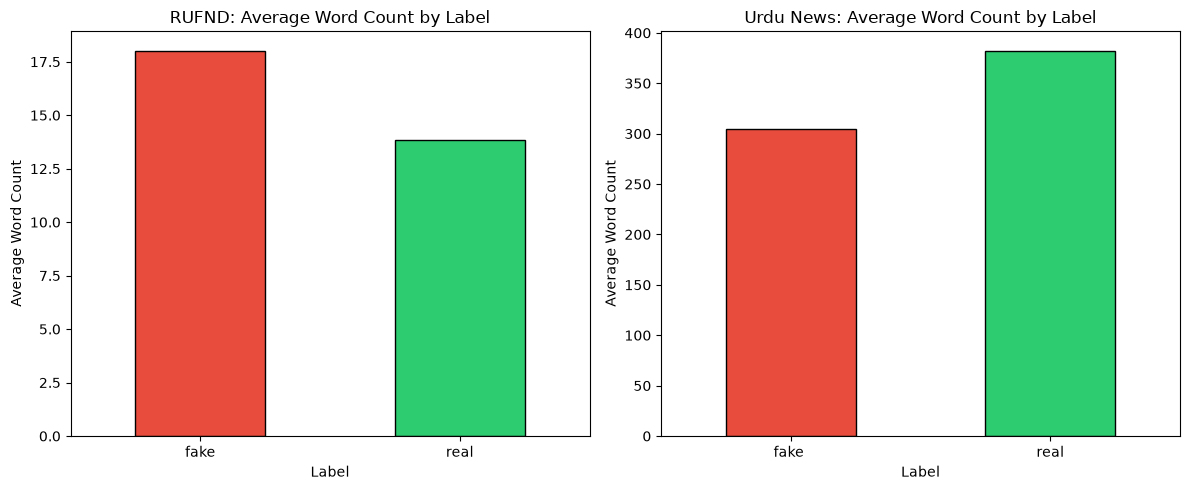

Chart saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RUFND word count by label
df_roman.groupby('label')['word_count'].mean().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[0].set_title('RUFND: Average Word Count by Label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Average Word Count')
axes[0].tick_params(axis='x', rotation=0)

# Urdu News word count by label
df_urdu.groupby('label')['word_count'].mean().plot(
    kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[1].set_title('Urdu News: Average Word Count by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Average Word Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/word_count_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")